# Roof Shape Training Inspector

Inspect training data, model predictions, and evaluation metrics for the
RoofNetV2 roof-shape classifier.

**Sections:**
1. Dataset inspection — view crops, class distribution, sample images per class
2. Training history — loss/accuracy curves, learning rate schedule
3. Model evaluation — confusion matrix, per-class accuracy, sample predictions
4. Error analysis — most confident mistakes, hardest classes

**Prerequisites:**
```bash
pip install torch torchvision matplotlib
# Run harvest + training first:
python -m tools.ml.data harvest
python -m tools.ml.train --task shape
```

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

from tools.ml.config import (
    SHAPE_LABELS, TRAIN_CITIES, EVAL_CITIES,
    DEFAULT_CROP_SIZE, DEFAULT_SHAPE_MODEL,
    IMAGENET_MEAN, IMAGENET_STD,
)

PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'output' / 'roof_crops'
MODEL_PATH = PROJECT_ROOT / DEFAULT_SHAPE_MODEL

print(f'Data dir : {DATA_DIR}')
print(f'Model    : {MODEL_PATH}')
print(f'Exists   : data={DATA_DIR.exists()}, model={MODEL_PATH.exists()}')

Data dir : C:\Users\eac84\OneDrive\Documents\Projects\3D Maps\Code\strm2stl\output\roof_crops
Model    : C:\Users\eac84\OneDrive\Documents\Projects\3D Maps\Code\strm2stl\models\roofnet_shape_v2.pt
Exists   : data=True, model=False


## 1. Dataset Inspection

Total samples: 1277


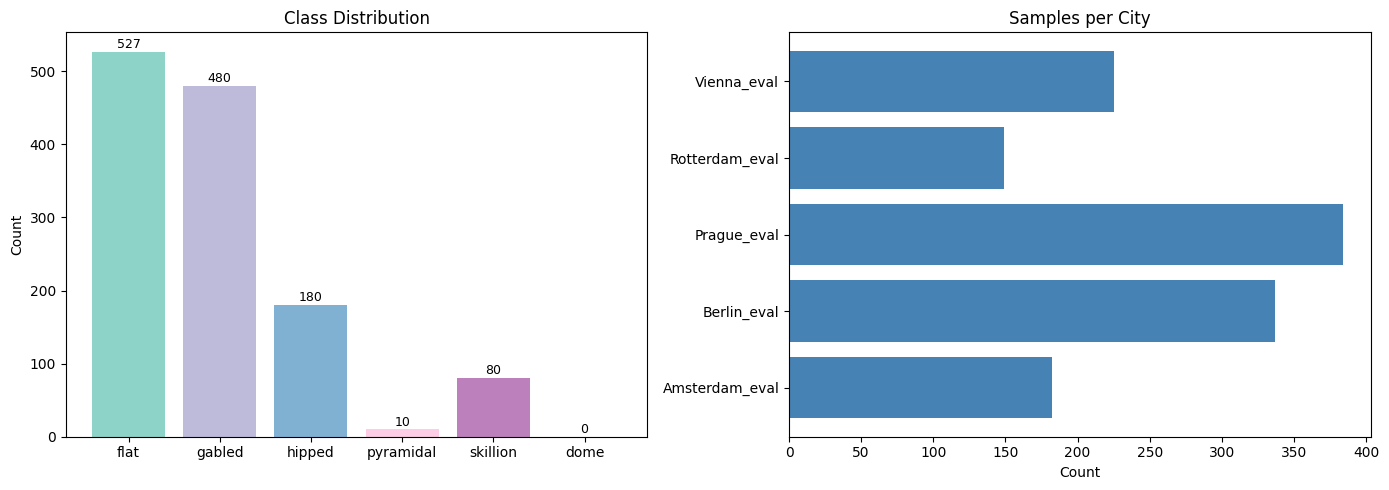

In [22]:
import csv

manifest = DATA_DIR / 'manifest.csv'
if not manifest.exists():
    print('No manifest found. Run harvest first:')
    print('  python -m tools.ml.data harvest')
else:
    rows = []
    with open(manifest, newline='', encoding='utf-8') as f:
        rows = list(csv.DictReader(f))
    
    print(f'Total samples: {len(rows)}')
    
    # Class distribution
    label_counts = Counter(r['label'] for r in rows)
    city_counts = Counter(r['city'] for r in rows)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar chart: class distribution
    labels = SHAPE_LABELS
    counts = [label_counts.get(l, 0) for l in labels]
    colors = plt.cm.Set3(np.linspace(0, 1, len(labels)))
    ax1.bar(labels, counts, color=colors)
    ax1.set_title('Class Distribution')
    ax1.set_ylabel('Count')
    for i, c in enumerate(counts):
        ax1.text(i, c + max(counts)*0.01, str(c), ha='center', fontsize=9)
    
    # Bar chart: city distribution
    cities = sorted(city_counts.keys())
    city_vals = [city_counts[c] for c in cities]
    ax2.barh(cities, city_vals, color='steelblue')
    ax2.set_title('Samples per City')
    ax2.set_xlabel('Count')
    
    plt.tight_layout()
    plt.show()

In [4]:
# Show sample images for each class
from PIL import Image

if manifest.exists():
    fig, axes = plt.subplots(len(SHAPE_LABELS), 6, figsize=(15, 3 * len(SHAPE_LABELS)))
    
    for row_idx, label in enumerate(SHAPE_LABELS):
        print(rows)
        
        label_rows = [r for r in rows if r['label'] == label]
        np.random.seed(42)
        samples = np.random.choice(len(label_rows), min(6, len(label_rows)), replace=False) if label_rows else []
        
        for col_idx in range(6):
            ax = axes[row_idx][col_idx] if len(SHAPE_LABELS) > 1 else axes[col_idx]
            if col_idx < len(samples):
                img_path = DATA_DIR / label_rows[samples[col_idx]]['path']
                if img_path.exists():
                    img = Image.open(img_path)
                    ax.imshow(img)
            ax.axis('off')
            print(col_idx)
            if col_idx == 0:
                print(f'{label}\n({len(label_rows)})')
                ax.set_title(f'{label}\n({len(label_rows)})', fontsize=11, rotation=0)
    
    plt.suptitle('Sample Crops by Class', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No data to display')

NameError: name 'manifest' is not defined

## 2. Training History

In [5]:
import json

# Check for both v1 and v2 history files
history_v2 = MODEL_PATH.parent / (MODEL_PATH.stem + '_history.json')
history_v1 = PROJECT_ROOT / 'models' / 'roofnet_shape_v1_history.json'

histories = {}
for label, path in [('v2 (MobileNetV3)', history_v2), ('v1 (Retna_V2)', history_v1)]:
    if path.exists():
        with open(path) as f:
            histories[label] = json.load(f)
        print(f'{label}: {path.name} loaded')

if not histories:
    print('No training history found. Train a model first.')

NameError: name 'MODEL_PATH' is not defined

In [6]:
# Plot training curves (compare v1 vs v2 if both exist)
if histories:
    n_plots = len(histories)
    fig, axes = plt.subplots(n_plots, 2, figsize=(14, 5 * n_plots), squeeze=False)
    
    for row, (label, data) in enumerate(histories.items()):
        h = data['history']
        epochs = [e['epoch'] for e in h]
        
        ax_loss = axes[row, 0]
        ax_loss.plot(epochs, [e['train_loss'] for e in h], label='train', alpha=0.8)
        ax_loss.plot(epochs, [e['val_loss'] for e in h], label='val', alpha=0.8)
        ax_loss.set_xlabel('Epoch')
        ax_loss.set_ylabel('Loss')
        ax_loss.set_title(f'{label} -- Loss')
        ax_loss.legend()
        ax_loss.grid(True, alpha=0.3)
        
        ax_acc = axes[row, 1]
        ax_acc.plot(epochs, [e['train_acc'] for e in h], label='train', alpha=0.8)
        ax_acc.plot(epochs, [e['val_acc'] for e in h], label='val', alpha=0.8)
        best_epoch = data.get('best_epoch', 0)
        best_acc = data.get('best_val_acc', 0)
        if best_epoch:
            ax_acc.axvline(best_epoch, color='red', linestyle='--', alpha=0.5)
            ax_acc.set_title(f'{label} -- Accuracy (best={best_acc:.3f} @ ep{best_epoch})')
        else:
            ax_acc.set_title(f'{label} -- Accuracy')
        ax_acc.set_xlabel('Epoch')
        ax_acc.set_ylabel('Accuracy')
        ax_acc.legend()
        ax_acc.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Per-class accuracy comparison
    print('\nPer-class accuracy:')
    print(f'{"Class":<12}', end='')
    for label in histories:
        print(f'{label:>20}', end='')
    print()
    print('-' * (12 + 20 * len(histories)))
    for cls in SHAPE_LABELS:
        print(f'{cls:<12}', end='')
        for label, data in histories.items():
            acc = data.get('per_class_acc', {}).get(cls, 0)
            print(f'{acc:>19.1%}', end='')
        print()

NameError: name 'histories' is not defined

## 3. Model Evaluation

In [19]:
# Evaluate the trained model (requires torch)
if manifest.exists():
    from tools.ml.eval import evaluate_shape_model, plot_confusion_matrix
    
    results = evaluate_shape_model(
        model_path=str(MODEL_PATH),
        data_dir=str(DATA_DIR),
        device='auto',
    )
    
    print(f'Overall accuracy: {results["accuracy"]:.3f}')
    print(f'Samples evaluated: {results["n_samples"]}')
    print()
    for lbl in SHAPE_LABELS:
        acc = results['per_class_accuracy'][lbl]
        cnt = results['per_class_count'][lbl]
        print(f'  {lbl:<12} {acc:.3f}  (n={cnt})')
else:
    
    print(MODEL_PATH.exists() ,manifest.exists())
    print('Model or data not found. Train first.')

Overall accuracy: 0.000
Samples evaluated: 337

  flat         0.000  (n=181)
  gabled       0.000  (n=103)
  hipped       0.000  (n=22)
  pyramidal    0.000  (n=1)
  skillion     0.000  (n=30)
  dome         0.000  (n=0)


In [20]:
# Confusion matrix
if MODEL_PATH.exists() and manifest.exists():
    fig = plot_confusion_matrix(
        results['confusion_matrix'],
        labels=SHAPE_LABELS,
        title='RoofNetV2 Confusion Matrix',
        save_path=str(PROJECT_ROOT / 'output' / 'roof_confusion_matrix.png'),
    )
    plt.show()

## 4. Sample Predictions

In [ ]:
# Show a grid of sample predictions with true vs predicted labels
if MODEL_PATH.exists() and manifest.exists():
    from tools.ml.eval import plot_sample_predictions
    
    fig = plot_sample_predictions(
        model_path=str(MODEL_PATH),
        data_dir=str(DATA_DIR),
        n_samples=20,
        crop_size=DEFAULT_CROP_SIZE,
        save_path=str(PROJECT_ROOT / 'output' / 'roof_sample_predictions.png'),
    )
    plt.show()

In [ ]:
# Error analysis: most confident wrong predictions
if MODEL_PATH.exists() and manifest.exists():
    preds = results['predictions']
    errors = [(true, pred, conf) for true, pred, conf in preds if true != pred]
    errors.sort(key=lambda x: -x[2])  # highest confidence first
    
    print(f'Total errors: {len(errors)} / {len(preds)} ({100*len(errors)/max(len(preds),1):.1f}%)')
    print()
    print('Top 15 most confident mistakes:')
    print(f'{"True":<12} {"Predicted":<12} {"Confidence":>10}')
    print('-' * 36)
    for true, pred, conf in errors[:15]:
        print(f'{true:<12} {pred:<12} {conf:>9.1%}')
    
    # Error confusion: which classes are most often confused?
    print()
    print('Most common confusions:')
    confusion_pairs = Counter((true, pred) for true, pred, _ in errors)
    for (true, pred), count in confusion_pairs.most_common(10):
        print(f'  {true} -> {pred}: {count}')

## 5. Quick Train (optional)

Run a quick training session from this notebook.

In [ ]:
# Uncomment to train from notebook:

# from tools.ml.train import train_shape, TrainConfig
# 
# cfg = TrainConfig(
#     task='shape',
#     epochs=60,
#     batch_size=16,
#     lr=3e-4,
#     crop_size=128,
#     patience=12,
#     freeze_backbone_epochs=5,
#     device='auto',
# )
# 
# result = train_shape(
#     data_dir='output/roof_crops',
#     output_model='models/roofnet_shape_v2.pt',
#     config=cfg,
# )
# print(f'Best val accuracy: {result["best_val_acc"]:.3f}')